In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [37]:
def relu(x):
    return x*(x>0)

In [38]:
duration = 1000
dt = 1
tau = 10
x = np.arange(duration)
W = []
M = []
Q = []
w, m, q = 0, 0, 0
for t in x:
    m += dt*(-m/tau + relu(np.random.normal(2, 2))*(np.random.random()>0.9))
    w = 20-(500-t)**2/20000
    M.append(m)
    q += dt*(-q/tau + 0.5*w/tau)
    W.append(w)
    Q.append(q+m)

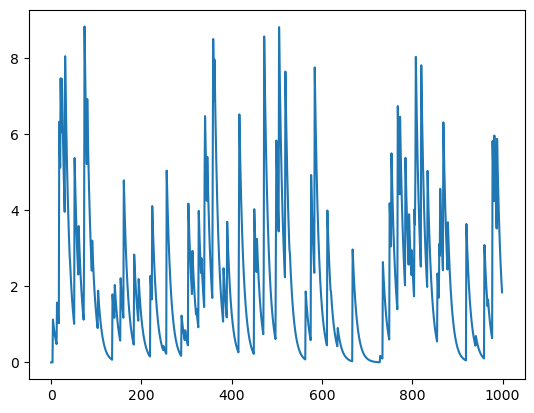

In [39]:
plt.plot(x, M)

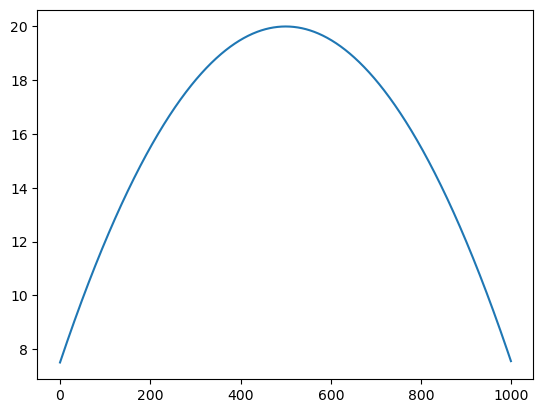

In [40]:
plt.plot(x, W)

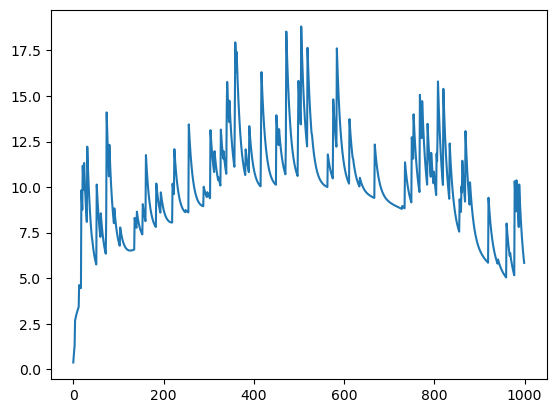

In [41]:
plt.plot(x, Q)

## QDA 

In [2]:
df = pd.read_excel('JJG.xlsx', date_format = str)#, header = 5, index_col=5)
df['date'] = df['date'].astype(str)

In [3]:
df[30:]

,date,rain gauge,Dt1,Rt1,It1,Eabs1,Ra1,Dt2,Rt2,It2,Eabs2,Ra2,Dt3,Rt3,It3,Eabs3,Ra3,occurrence
30,2007/7/25(1),G1,10.333300,20.4,1.974200,2.14,44.4418,2.533300,6.1,2.407926,0.67,44.4418,2.450000,6.2,2.530612,0.71,44.4418,1.0
31,2007/7/25(1),G2,7.566700,45.6,6.026405,9.42,52.0771,4.750000,25.2,5.305263,5.40,52.0771,5.200000,32.9,6.326923,8.09,52.0771,1.0
32,2007/7/25(1),G3,9.950000,34.0,3.417085,6.46,50.0343,4.100000,20.3,4.951220,5.05,50.0343,4.116700,20.4,4.955425,5.09,50.0343,1.0
33,2007/7/25(1),G4,9.616700,29.3,3.046783,3.39,38.7768,3.783300,15.1,3.991225,1.89,38.7768,3.783300,15.1,3.991225,1.89,38.7768,1.0
34,2007/7/25(1),G5,9.666700,16.1,1.665511,1.70,41.3749,0.883300,2.7,3.056719,0.29,41.3749,0.916700,2.9,3.163521,0.33,41.3749,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,2023-07-27 00:00:00,G1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
701,2023-07-27 00:00:00,G2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
702,2023-07-27 00:00:00,G3,1.583333,7.0,4.421053,0.90,11.5244,0.550000,4.0,7.272727,0.54,11.5244,0.550000,4.0,7.272727,0.54,11.5244,0.0
703,2023-07-27 00:00:00,G4,5.333333,32.8,6.150000,11.88,4.7066,0.533333,9.5,17.812500,5.31,4.7066,0.783333,15.9,20.297872,9.31,4.7066,0.0


In [4]:
date = np.unique(df['date'])
site = np.unique(df['rain gauge'])
features = ['Dt', 'Rt', 'It', 'Eabs', 'Ra']
print('date: ', date)
print('site: ', site)
print('feature : ', features)

date:  ['2006-05-25 00:00:00' '2006-05-27 00:00:00' '2006-05-29 00:00:00'
 '2006-06-07 00:00:00' '2006-06-27 00:00:00' '2006-06-30 00:00:00'
 '2006-07-05 00:00:00' '2006-07-06 00:00:00' '2006-07-18 00:00:00'
 '2006-07-24 00:00:00' '2006-08-07 00:00:00' '2006-08-13 00:00:00'
 '2006-08-15 00:00:00' '2006-08-20 00:00:00' '2006-09-08 00:00:00'
 '2006-09-15 00:00:00' '2006-09-30 00:00:00' '2006-10-07 00:00:00'
 '2007-04-28 00:00:00' '2007-05-16 00:00:00' '2007-06-12 00:00:00'
 '2007-07-10 00:00:00' '2007-07-12 00:00:00' '2007-07-19 00:00:00'
 '2007-07-24 00:00:00' '2007-07-30 00:00:00' '2007-08-11 00:00:00'
 '2007-08-20 00:00:00' '2007-08-25 00:00:00' '2007-09-14 00:00:00'
 '2007-09-17 00:00:00' '2007/7/25(1)' '2007/7/25(2)' '2008-02-19 00:00:00'
 '2008-03-08 00:00:00' '2008-05-05 00:00:00' '2008-06-04 00:00:00'
 '2008-06-11 00:00:00' '2008-06-23 00:00:00' '2008-06-26 00:00:00'
 '2008-07-01 00:00:00' '2008-07-03 00:00:00' '2008-07-05 00:00:00'
 '2008-07-22 00:00:00' '2008-07-31 00:00:00' '2

In [5]:
import itertools

# Your list of strings

# Get all possible combinations
all_combinations = []
for r in range(1, len(features) + 1):
    combinations = list(itertools.combinations(features, r))
    all_combinations.extend(combinations)

# Convert combinations to list of lists if needed
all_combinations = [list(comb) for comb in all_combinations]
print(all_combinations)

[['Dt'], ['Rt'], ['It'], ['Eabs'], ['Ra'], ['Dt', 'Rt'], ['Dt', 'It'], ['Dt', 'Eabs'], ['Dt', 'Ra'], ['Rt', 'It'], ['Rt', 'Eabs'], ['Rt', 'Ra'], ['It', 'Eabs'], ['It', 'Ra'], ['Eabs', 'Ra'], ['Dt', 'Rt', 'It'], ['Dt', 'Rt', 'Eabs'], ['Dt', 'Rt', 'Ra'], ['Dt', 'It', 'Eabs'], ['Dt', 'It', 'Ra'], ['Dt', 'Eabs', 'Ra'], ['Rt', 'It', 'Eabs'], ['Rt', 'It', 'Ra'], ['Rt', 'Eabs', 'Ra'], ['It', 'Eabs', 'Ra'], ['Dt', 'Rt', 'It', 'Eabs'], ['Dt', 'Rt', 'It', 'Ra'], ['Dt', 'Rt', 'Eabs', 'Ra'], ['Dt', 'It', 'Eabs', 'Ra'], ['Rt', 'It', 'Eabs', 'Ra'], ['Dt', 'Rt', 'It', 'Eabs', 'Ra']]


In [6]:
df_avg = df[df['rain gauge']!='G5'].groupby('date').mean(numeric_only=True).reset_index()

In [7]:
df_avg

,date,Dt1,Rt1,It1,Eabs1,Ra1,Dt2,Rt2,It2,Eabs2,Ra2,Dt3,Rt3,It3,Eabs3,Ra3,occurrence
0,2006-05-25 00:00:00,9.450000,9.95,1.051825,1.045,10.13775,5.391650,6.40,1.541340,0.670,10.13775,5.391650,6.40,1.541340,0.670,10.13775,0.0
1,2006-05-27 00:00:00,12.008350,30.85,2.773086,5.105,17.26480,6.991650,13.85,2.004060,2.855,17.26480,7.175000,16.10,2.261051,3.400,17.26480,0.0
2,2006-05-29 00:00:00,20.083350,13.30,0.698979,1.450,36.42395,14.108350,9.00,0.688886,1.000,36.42395,14.108350,9.00,0.688886,1.000,36.42395,0.0
3,2006-06-07 00:00:00,1.658350,12.80,7.648731,3.970,7.49305,0.358300,5.30,14.125744,2.090,7.49305,0.550000,9.00,15.535714,3.460,7.49305,0.0
4,2006-06-27 00:00:00,3.783350,18.05,4.773255,4.775,5.17945,0.841700,5.70,6.942775,2.070,5.17945,1.033350,9.85,9.826699,3.845,5.17945,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,2023-05-13 00:00:00,6.258333,8.40,1.447605,1.120,0.26965,3.758333,4.75,1.320391,0.685,0.26965,3.758350,4.75,1.320389,0.685,0.26965,0.0
137,2023-05-15 00:00:00,4.341667,1.95,0.469728,0.215,5.71660,4.341650,1.95,0.469732,0.215,5.71660,4.341650,1.95,0.469732,0.215,5.71660,0.0
138,2023-06-08 00:00:00,11.408350,45.25,4.513163,9.355,2.14465,3.658317,13.60,6.058310,3.550,2.14465,3.850017,16.75,6.834211,4.645,2.14465,0.0
139,2023-07-27 00:00:00,3.458333,19.90,5.285526,6.390,8.11550,0.541667,6.75,12.542614,2.925,8.11550,0.666667,9.95,13.785300,4.925,8.11550,0.0


In [8]:
sites = [['G5'], ['G3'], ['G1', 'G2', 'G3', 'G4']]

In [9]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, fbeta_score, f1_score, precision_score, recall_score, accuracy_score

Thresholds = np.arange(0.1, 0.52, 0.02)

result = []
for i in range(1, 4):
    for fs in all_combinations:
        for s in sites:
            r = {}            
            X = []
            if len(s)==1:
                for f in fs:
                    con1=(df['rain gauge']==s[0])
                    con2=(df['occurrence'].notnull())
                    x = df[f+str(i)][con1 & con2]
                    X.append(x)
                    y = np.array(df['occurrence'][con1 & con2])
            else:
                for f in fs:
                    con2=df_avg['occurrence'].notnull()
                    x = df_avg[f+str(i)][con2]
                    X.append(x)
                    y = np.array(df_avg['occurrence'][con2])
            X=np.array(X).T
            
            clf = QuadraticDiscriminantAnalysis()
            clf.fit(X, y)
            
            y_pred_prob = clf.predict_proba(X)[:, 1]
            
            r['phase'] = i
            r['factors']= ''.join(fs)
            r['site']=''.join(s)
            r['score']=clf.score(X, y)

            for threshold in Thresholds:
            # Set the threshold
            
                y_pred = (y_pred_prob >= threshold).astype(int)
            #y_pred = clf.predict(X)
            

            # Calculate confusion matrix
                tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

            # Calculate precision and recall
                precision = precision_score(y, y_pred)
                recall = recall_score(y, y_pred)

            # Calculate F2 score
                f1 = f1_score(y, y_pred)
                f2 = fbeta_score(y, y_pred, beta=2)

            #r['predictor']=clf.predict
            
                r['accuracy_%.2f'%threshold]= accuracy_score(y, y_pred)
                r['F1_%.2f'%threshold]=f1
                r['F2_%.2f'%threshold]=f2
                r['precision_%.2f'%threshold]=precision
                r['recall_%.2f'%threshold]=recall
            result.append(r)
            

C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no pr

C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no pr

C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no pr

In [10]:
dfr = pd.DataFrame(result)

In [11]:
dfr

,phase,factors,site,score,accuracy_0.10,F1_0.10,F2_0.10,precision_0.10,recall_0.10,accuracy_0.12,...,accuracy_0.48,F1_0.48,F2_0.48,precision_0.48,recall_0.48,accuracy_0.50,F1_0.50,F2_0.50,precision_0.50,recall_0.50
0,1,Dt,G5,0.736434,0.325581,0.431373,0.647059,0.277311,0.970588,0.348837,...,0.736434,0.000000,0.000000,0.000000,0.000000,0.736434,0.000000,0.000000,0.000000,0.000000
1,1,Dt,G3,0.717391,0.362319,0.463415,0.676157,0.304000,0.974359,0.362319,...,0.717391,0.000000,0.000000,0.000000,0.000000,0.717391,0.000000,0.000000,0.000000,0.000000
2,1,Dt,G1G2G3G4,0.714286,0.385714,0.475610,0.686620,0.314516,0.975000,0.400000,...,0.714286,0.000000,0.000000,0.000000,0.000000,0.714286,0.000000,0.000000,0.000000,0.000000
3,1,Rt,G5,0.744186,0.263566,0.417178,0.641509,0.263566,1.000000,0.263566,...,0.736434,0.227273,0.171233,0.500000,0.147059,0.744186,0.195122,0.139860,0.571429,0.117647
4,1,Rt,G3,0.717391,0.282609,0.440678,0.663265,0.282609,1.000000,0.282609,...,0.717391,0.000000,0.000000,0.000000,0.000000,0.717391,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,3,RtItEabsRa,G3,0.760870,0.572464,0.562963,0.753968,0.395833,0.974359,0.623188,...,0.768116,0.500000,0.441989,0.640000,0.410256,0.760870,0.459016,0.393258,0.636364,0.358974
275,3,RtItEabsRa,G1G2G3G4,0.778571,0.728571,0.641509,0.752212,0.515152,0.850000,0.735714,...,0.778571,0.550725,0.502646,0.655172,0.475000,0.778571,0.550725,0.502646,0.655172,0.475000
276,3,DtRtItEabsRa,G5,0.713178,0.441860,0.478261,0.687500,0.317308,0.970588,0.457364,...,0.689922,0.354839,0.335366,0.392857,0.323529,0.713178,0.372881,0.341615,0.440000,0.323529
277,3,DtRtItEabsRa,G3,0.818841,0.528986,0.539007,0.736434,0.372549,0.974359,0.543478,...,0.782609,0.651163,0.689655,0.595745,0.717949,0.818841,0.691358,0.707071,0.666667,0.717949


In [12]:
dfr.to_csv('result.csv')

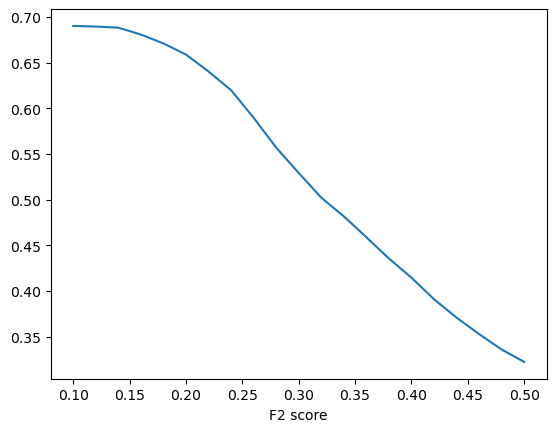

In [13]:
F2 = []
for threshold in Thresholds:
    F2.append(dfr['F2_%.2f'%threshold].mean())

fig = plt.figure()
plt.plot(Thresholds, F2)
plt.xlabel('threshold')
plt.xlabel('F2 score')
plt.show()

In [12]:
from sklearn import svm

Thresholds = [0] #np.arange(-1.0, 0.5, 0.1)
result_svm = []
optim_clf=None
X_train=None
optim_F2=0

for i in range(1, 4):
    for fs in all_combinations:
        for s in sites:
            r = {}            
            X = []
            if len(s)==1:
                for f in fs:
                    con1=(df['rain gauge']==s[0])
                    con2=(df['occurrence'].notnull())
                    x = df[f+str(i)][con1 & con2]
                    X.append(x)
                    y = np.array(df['occurrence'][con1 & con2])
            else:
                for f in fs:
                    con2=df_avg['occurrence'].notnull()
                    x = df_avg[f+str(i)][con2]
                    X.append(x)
                    y = np.array(df_avg['occurrence'][con2])
            X=np.array(X).T
            
            #Create a svm Classifier
            clf = svm.SVC(kernel='rbf')
            clf.fit(X, y, sample_weight = y*2+1)
            
            decision_scores = clf.decision_function(X)
            
            r['phase'] = i
            r['factors']= ''.join(fs)
            r['site']=''.join(s)
            r['score']=clf.score(X, y)

            for threshold in Thresholds:
            # Set the threshold
            
                y_pred = (decision_scores >= threshold).astype(int)
            #y_pred = clf.predict(X)
            

            # Calculate confusion matrix
                tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

            # Calculate precision and recall
                precision = precision_score(y, y_pred)
                recall = recall_score(y, y_pred)

            # Calculate F2 score
                f1 = f1_score(y, y_pred)
                f2 = fbeta_score(y, y_pred, beta=2)
                
                if i==2 and len(s)!=1 and len(fs)==5:
                    optim_clf=clf
                    X_train=X
            
                r['accuracy_%.2f'%threshold]= accuracy_score(y, y_pred)
                r['F1_%.2f'%threshold]=f1
                r['F2_%.2f'%threshold]=f2
                r['precision_%.2f'%threshold]=precision
                r['recall_%.2f'%threshold]=recall
                
            result_svm.append(r)

In [13]:
dfr_svm = pd.DataFrame(result_svm)
dfr_svm.to_csv('result_svm.csv')
dfr_svm

,phase,factors,site,score,accuracy_-1.00,F1_-1.00,F2_-1.00,precision_-1.00,recall_-1.00,accuracy_-0.90,...,accuracy_0.30,F1_0.30,F2_0.30,precision_0.30,recall_0.30,accuracy_0.40,F1_0.40,F2_0.40,precision_0.40,recall_0.40
0,1,Dt,G5,0.573643,0.387597,0.455172,0.668016,0.297297,0.970588,0.410853,...,0.612403,0.390244,0.434783,0.333333,0.470588,0.635659,0.373333,0.395480,0.341463,0.411765
1,1,Dt,G3,0.572464,0.347826,0.464286,0.684211,0.302326,1.000000,0.413043,...,0.608696,0.386364,0.414634,0.346939,0.435897,0.608696,0.357143,0.373134,0.333333,0.384615
2,1,Dt,G1G2G3G4,0.421429,0.364286,0.473373,0.692042,0.310078,1.000000,0.378571,...,0.435714,0.483660,0.677656,0.327434,0.925000,0.428571,0.473684,0.661765,0.321429,0.900000
3,1,Rt,G5,0.674419,0.356589,0.402878,0.580913,0.266667,0.823529,0.558140,...,0.689922,0.393939,0.386905,0.406250,0.382353,0.682171,0.369231,0.359281,0.387097,0.352941
4,1,Rt,G3,0.673913,0.355072,0.440252,0.634058,0.291667,0.897436,0.543478,...,0.673913,0.383562,0.368421,0.411765,0.358974,0.681159,0.388889,0.370370,0.424242,0.358974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,3,RtItEabsRa,G3,0.804348,0.550725,0.537313,0.717131,0.378947,0.923077,0.637681,...,0.833333,0.722892,0.750000,0.681818,0.769231,0.840580,0.717949,0.717949,0.717949,0.717949
275,3,RtItEabsRa,G1G2G3G4,0.821429,0.585714,0.567164,0.748031,0.404255,0.950000,0.628571,...,0.814286,0.717391,0.778302,0.634615,0.825000,0.807143,0.703297,0.758294,0.627451,0.800000
276,3,DtRtItEabsRa,G5,0.713178,0.480620,0.496241,0.702128,0.333333,0.970588,0.511628,...,0.759690,0.617284,0.683060,0.531915,0.735294,0.759690,0.607595,0.662983,0.533333,0.705882
277,3,DtRtItEabsRa,G3,0.826087,0.572464,0.549618,0.725806,0.391304,0.923077,0.666667,...,0.847826,0.734177,0.739796,0.725000,0.743590,0.855072,0.743590,0.743590,0.743590,0.743590


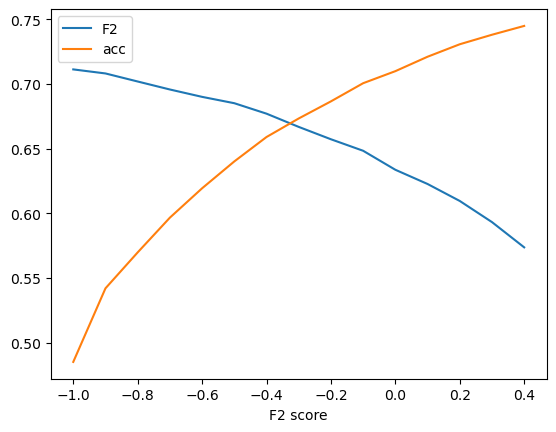

In [12]:
F2 = []
Acc = []
for threshold in Thresholds:
    F2.append(dfr_svm['F2_%.2f'%threshold].mean())
    Acc.append(dfr_svm['accuracy_%.2f'%threshold].mean())

fig = plt.figure()
plt.plot(Thresholds, F2, label='F2')
plt.plot(Thresholds, Acc, label='acc')

plt.xlabel('threshold')
plt.xlabel('F2 score')
plt.legend()
plt.show()

Using 140 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/140 [00:00<?, ?it/s]

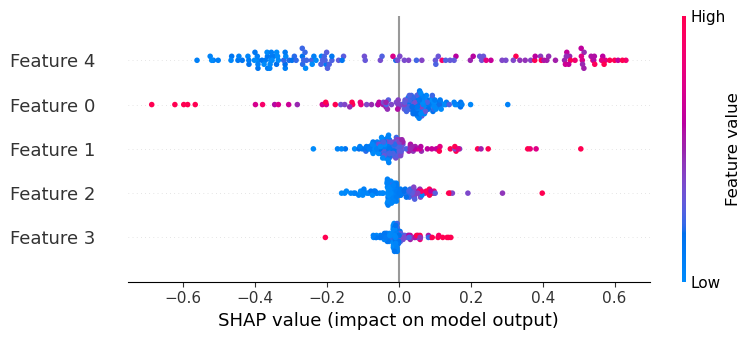

In [19]:
import shap
explainer = shap.KernelExplainer(optim_clf.predict, X_train)
shap_values = explainer(X_train)
shap.summary_plot(shap_values, X_train)

In [23]:
df_shap = pd.DataFrame(shap_values.values)
df_shap.to_csv('shap.csv')

In [13]:
para=optim_clf.get_params()
para

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [14]:
sv = optim_clf.support_vectors_
dc = optim_clf.dual_coef_
ic = optim_clf.intercept_


In [15]:
print(sv, dc, ic)

[[ 6.99165    13.85        2.00406013  2.855      17.2648    ]
 [14.10835     9.          0.6888856   1.         36.42395   ]
 [ 0.3583      5.3        14.1257438   2.09        7.49305   ]
 [ 4.525      11.5         2.84245138  2.31       12.67035   ]
 [ 3.90835     6.35        1.59884329  1.235      13.21605   ]
 [ 5.49165    12.95        2.35622906  3.075      10.7585    ]
 [ 0.15        3.7        30.95559001  2.39        4.3717    ]
 [ 1.60835     3.95        2.70108759  1.635      11.0282    ]
 [ 2.25        5.9        18.4137931   0.67       10.42625   ]
 [ 4.970825   13.35        2.71465766  1.925      14.774575  ]
 [ 1.7375      9.6         8.10946263  7.38       20.71045   ]
 [ 6.9375     12.175       1.68224002  2.1225     12.222825  ]
 [ 0.316675    8.2        27.16555689  7.67        6.05855   ]
 [ 9.866675   22.1         3.00661929  3.155      21.4241    ]
 [ 4.025      14.175       4.0402948   1.7525     10.39045   ]
 [ 0.75556667  6.73333333 12.30623148  2.12        6.54

In [19]:
sv.shape

(87, 5)

In [18]:
optim_clf._gamma

0.001977512671913673